In [1]:
import torch
from torch import nn
from d2l import torch as d2l
from torch.nn import functional as F

GoogLeNet (also known as Inception-v1) is a masterclass in computational efficiency. Winning the ILSVRC 2014 challenge, it achieved state-of-the-art accuracy while using only roughly 5 million parameters—a staggering $12\times$ fewer than AlexNet, despite being much deeper (22 layers).

The secret to this efficiency lies in its fundamental building block: the **Inception Module**.

### 1. The Motivation Behind Inception

In traditional CNNs (like VGG or AlexNet), the architect must make a rigid choice at every layer: should I use a $1 \times 1$, $3 \times 3$, or $5 \times 5$ filter, or perhaps a max-pooling operation?

The problem is that visual information in an image appears at different scales. A dog might occupy the entire frame in one image (requiring large $5 \times 5$ filters to capture global patterns), but only a tiny corner in another (requiring small $1 \times 1$ or $3 \times 3$ filters for fine details).

The Inception module solves this by asking: *Why choose? Let's use all of them at the same time.*

### 2. The Naive Inception Module

In its most basic form, an Inception block takes the input feature map and passes it through four parallel branches simultaneously:

1. A $1 \times 1$ convolution
2. A $3 \times 3$ convolution
3. A $5 \times 5$ convolution
4. A $3 \times 3$ max-pooling operation

The outputs of these four branches are then concatenated along the channel dimension to form a single, massive output tensor. The network dynamically learns which branches (scales) are most useful for the given input by adjusting the weights during training.

**The Fatal Flaw:** The naive module is computationally disastrous. If you pass a 256-channel input directly into a $5 \times 5$ convolution with 256 output channels, the number of floating-point operations (FLOPs) explodes. Furthermore, concatenating the outputs of all four branches means the channel depth grows exponentially as you stack these modules.

### 3. The Solution: Dimensionality Reduction ($1 \times 1$ Convolutions)

To make the parallel branching mathematically viable, the authors introduced the concept of **bottleneck layers** using $1 \times 1$ convolutions.

Before applying the expensive $3 \times 3$ and $5 \times 5$ convolutions, the input feature map is first passed through a $1 \times 1$ convolution with a small number of filters.

* **The Math:** Suppose you have an input of shape $256 \times 14 \times 14$. If you apply a $5 \times 5$ filter with 64 output channels directly, it requires $(5 \times 5 \times 256) \times 64 = 409,600$ operations per spatial pixel.
* **The Bottleneck Trick:** If you first apply a $1 \times 1$ convolution to compress the 256 channels down to 16 channels, and *then* apply the $5 \times 5$ filter to output 64 channels, the cost becomes $(1 \times 1 \times 256 \times 16) + (5 \times 5 \times 16 \times 64) = 4,096 + 25,600 = 29,696$ operations.

By inserting these $1 \times 1$ convolutions, the computational cost is reduced by more than a factor of 10 without sacrificing the representational power of the network.

### 4. The GoogLeNet Macro-Architecture

GoogLeNet stacks 9 of these optimized Inception modules on top of one another. To make this 22-layer behemoth train effectively, the authors implemented two additional architectural breakthroughs:

* **Auxiliary Classifiers:** Training very deep networks is plagued by the vanishing gradient problem, where error signals from the final loss function die out before reaching the early layers. GoogLeNet solves this by attaching two smaller "auxiliary" classification heads to the intermediate Inception modules. During training, these heads calculate a loss and inject gradients directly into the middle of the network, forcing the intermediate layers to learn highly discriminative features early on. (These auxiliary heads are discarded during inference).
* **Global Average Pooling (GAP):** Borrowing directly from the "Network in Network" (NiN) philosophy, GoogLeNet completely eliminates the massive, memory-heavy fully connected layers at the end of the network. Instead, it applies Global Average Pooling to the final $7 \times 7$ feature maps, collapsing them into a 1D vector before a single linear classification layer. This decision alone removed millions of parameters and acted as a powerful structural regularizer against overfitting.

## Inception block structure

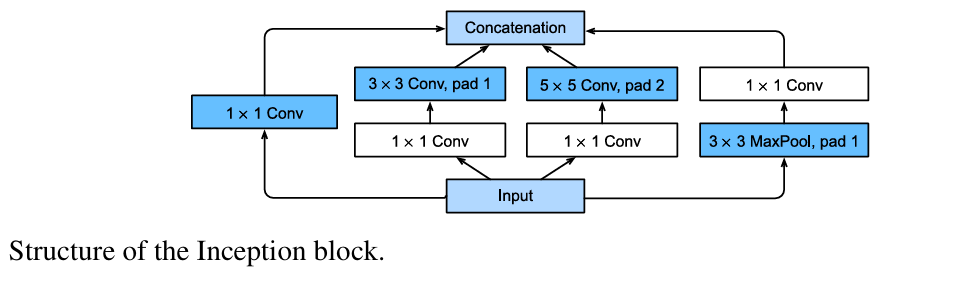

In [13]:
class Inception(nn.Module):
    def __init__(self, c1, c2, c3, c4, **kwargs):
        super(Inception, self).__init__(**kwargs)
        #Branch 1
        self.b1_1 = nn.LazyConv2d(c1, kernel_size=1)
        #Branch 2
        self.b2_1 = nn.LazyConv2d(c2[0], kernel_size=1)
        self.b2_2 = nn.LazyConv2d(c2[1], kernel_size=3, padding=1)
        #Branch 3
        self.b3_1 = nn.LazyConv2d(c3[0], kernel_size=1)
        self.b3_2 = nn.LazyConv2d(c3[1], kernel_size=5, padding=2) 
        #Branch 4
        self.b4_1 = nn.MaxPool2d(kernel_size=3, stride=1, padding=1)
        self.b4_2 = nn.LazyConv2d(c4, kernel_size=1)

    def forward(self, x):
        b1 = F.relu(self.b1_1(x))
        b2 = F.relu(self.b2_2(F.relu(self.b2_1(x))))
        b3 = F.relu(self.b3_2(F.relu(self.b3_1(x))))
        b4 = F.relu(self.b4_2(self.b4_1(x)))

        return torch.cat((b1, b2, b3, b4), dim=1)


## GoogLeNet structure

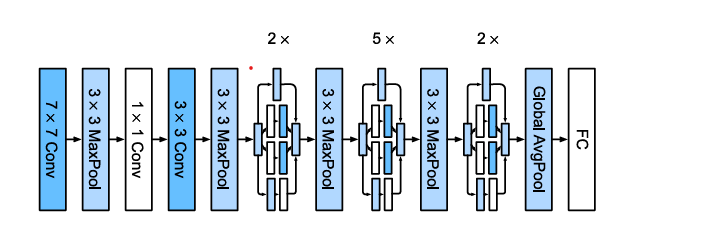

In [14]:
class GoogLeNet(d2l.Classifier):

    def __init__(self, lr=0.1, num_classes=10):

        super(GoogLeNet, self).__init__()
        self.save_hyperparameters()

        self.net = nn.Sequential(
            self.b1(),
            self.b2(),
            self.b3(),
            self.b4(),
            self.b5(),
            nn.LazyLinear(out_features=num_classes)
        )
        self.net.apply(d2l.init_cnn)


    def b1(self):
        return nn.Sequential(
            nn.LazyConv2d(out_channels=64, kernel_size=7, stride=2, padding=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
    
    def b2(self):
        return nn.Sequential(
            nn.LazyConv2d(out_channels=64, kernel_size=1),
            nn.LazyConv2d(out_channels=192, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
    
    def b3(self):
        return nn.Sequential(
            Inception(c1=64, c2=(96, 128), c3=(16, 32), c4=32),
            Inception(c1=128, c2=(128, 192), c3=(32, 96), c4=64),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

    def b4(self):
        return nn.Sequential(
            Inception(c1=192, c2=(96, 208), c3=(16, 48), c4=64),
            Inception(c1=160, c2=(112, 224), c3=(24, 64), c4=64),
            Inception(c1=128, c2=(128, 256), c3=(24, 64), c4=64),
            Inception(c1=112, c2=(144, 288), c3=(32, 64), c4=64),
            Inception(c1=256, c2=(160, 320), c3=(32, 128), c4=128),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
    
    def b5(self):
        return nn.Sequential(
            Inception(c1=256, c2=(160, 320), c3=(32, 128), c4=128),
            Inception(c1=384, c2=(192, 384), c3=(48, 128), c4=128),
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten()
        )

In [15]:
model = GoogLeNet().layer_summary((1, 1, 96, 96))

Sequential output shape:	 torch.Size([1, 64, 24, 24])
Sequential output shape:	 torch.Size([1, 192, 12, 12])
Sequential output shape:	 torch.Size([1, 480, 6, 6])
Sequential output shape:	 torch.Size([1, 832, 3, 3])
Sequential output shape:	 torch.Size([1, 1024])
Linear output shape:	 torch.Size([1, 10])


In [ ]:
model = GoogLeNet(lr=0.01)
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
data = d2l.FashionMNIST(batch_size=128, resize=(96, 96))
model.apply_init([next(iter(data.get_dataloader(True)))[0]], d2l.init_cnn)
trainer.fit(model, data)